# Regrid

The unstructured mesh is optimal for computations and storage because it reduces the number of computational elements. However, using structured netcdf, zarr, or tiff can be preferable for some analysis and plot making.

In [40]:
import CHM as pc
import uxarray as ux
import rioxarray as rio
import xarray as xr
import matplotlib.pyplot as plt

In [ ]:
# If the mesh requires out of core compute, spin up a dask cluster

from dask_jobqueue import PBSCluster
from dask.distributed import Client

cluster = PBSCluster(
    cores=80,
    processes=40,
    memory='185GB',
    interface='ib0',
    local_directory='$TMPDIR',
    queue='development',
    walltime='06:00:00',
    job_script_prologue=["spack env activate analysis"]
)
print(cluster.job_script())
cluster.scale(jobs=25)
client = Client(cluster)
client

In [2]:
# Here, we are using a single timestep for a subset domain for air temp
# note that global_id is preserved as it must be in both the mesh and vars .nc in order to line up elements
ds = ux.open_mfdataset('mesh_subset.nc', 'vars_subset.nc')
ds

<xarray.UxDataset> Size: 5MB
Dimensions:       (n_face: 142546)
Coordinates:
    time          datetime64[ns] 8B ...
    Mesh2_face_x  (n_face) float64 1MB dask.array<chunksize=(142546,), meta=np.ndarray>
    Mesh2_face_y  (n_face) float64 1MB dask.array<chunksize=(142546,), meta=np.ndarray>
Dimensions without coordinates: n_face
Data variables:
    t             (n_face) float64 1MB dask.array<chunksize=(142546,), meta=np.ndarray>
    global_id     (n_face) uint64 1MB dask.array<chunksize=(142546,), meta=np.ndarray>

pyCHM is built on top of Uxarray, and thus can use the Uxarray regridding for small domains. Small is defined as anything that can be gridded on a single compute node as the underlying regridding is cython and not parallel across dask
https://uxarray.readthedocs.io/en/latest/user-guide/remapping.html
Which the uxarray regridder can be used directly, the `.chm.regrid` version handles the grid creation and other minutia.

In [3]:
# Regrid using the uxarray regridding
rg_01 = ds.chm.regrid(0.01) # in degrees
rg_001 = ds.chm.regrid(0.001)

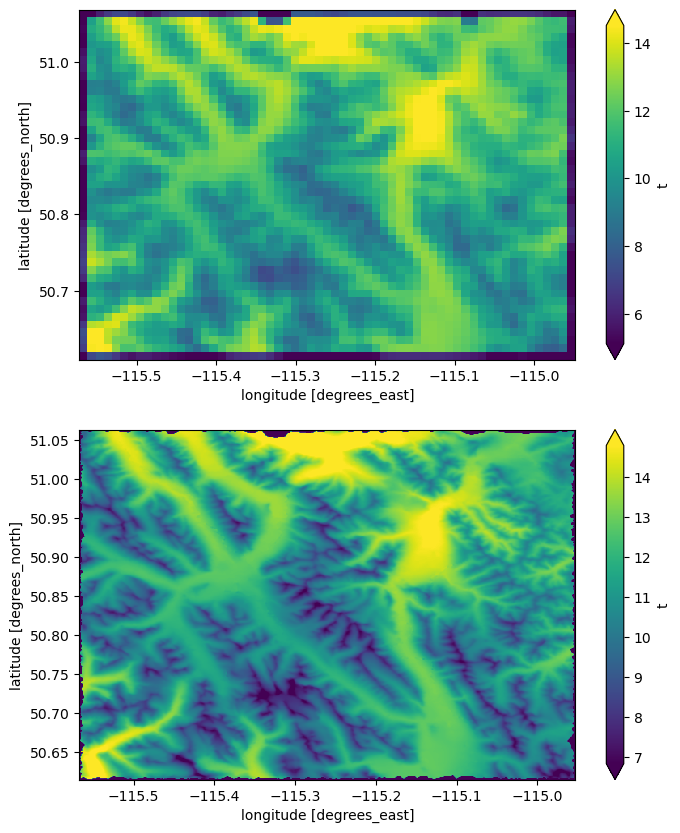

In [10]:
fig, ax = plt.subplots(nrows=2,figsize=(8,10))
rg_01.t.plot(ax=ax[0], robust=True)
rg_001.t.plot(ax=ax[1],  robust=True)

These can then me saved to a gridded format of choice that xarray can write

In [ ]:
# GeoTiff
tiff = rg_01.rio.write_crs('+proj=longlat +datum=WGS84 +no_defs +type=crs')
tiff.t.rio.to_raster('test.tiff')

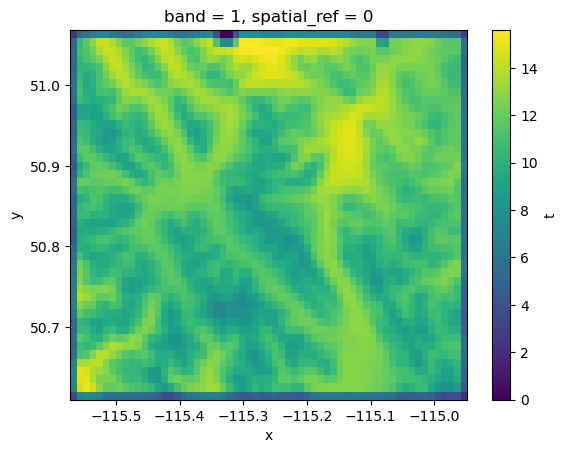

In [ ]:
tiff = rio.open_rasterio('test.tiff')
tiff.plot()

However, with large meshes, using the `chm.regrid` will run out of memory. Then it's time for the chm_ugrid2grid, which is an MPI backed regridder built on top of ESMF. It supports conservative and bilinear regridding. 
This tool doesn't use Dask, so needs to be invoked with `mpirun` or similar. It writes to zarr or tiff.

In [29]:
%%bash
# the variable.nc MUST have global_id var and time dimension
# the mesh.nc MUST have global_id var
mpirun --mca btl_tcp_if_include ib0 -n 5 python ~/project-ords/code/pyCHM/src/CHM/tools/ugrid2grid.py vars_subset.nc --mesh mesh_subset.nc --dxdy 0.001 --method conservative --variables t --zarr-output subset.zarr --overwrite


[0] Initializing Zarr store at subset.zarr
[0] 20161001T000000 - t
[2] 20161001T000000 - t
[3] 20161001T000000 - t
[4] 20161001T000000 - t
[1] 20161001T000000 - t
[4] 20161001T010000 - t
[3] 20161001T010000 - t
[2] 20161001T010000 - t
[0] 20161001T010000 - t
[1] 20161001T010000 - t


In [ ]:
ds = xr.open_zarr('subset.zarr', consolidated=False) # because of how the zarr is written in parallel it doesn't have consolidated metadata
ds

<xarray.Dataset> Size: 2MB
Dimensions:      (time: 2, latitude: 448, longitude: 613)
Coordinates:
  * time         (time) datetime64[ns] 16B 2016-10-01 2016-10-01T01:00:00
  * longitude    (longitude) float64 5kB -115.6 -115.6 -115.6 ... -115.0 -115.0
  * latitude     (latitude) float64 4kB 50.62 50.62 50.62 ... 51.06 51.06 51.06
Data variables:
    t            (time, latitude, longitude) float32 2MB dask.array<chunksize=(1, 448, 512), meta=np.ndarray>
    spatial_ref  int8 1B ...
Attributes:
    Conventions:     CF-1.8, GeoZarr-1.0
    geospatial_crs:  EPSG:4326

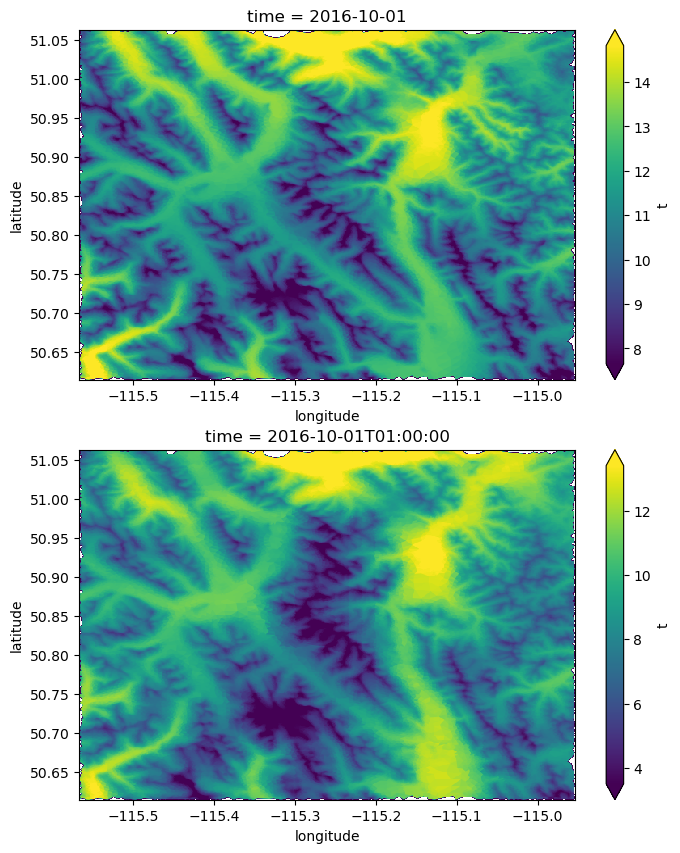

In [35]:

fig, ax = plt.subplots(nrows=2,figsize=(8,10))
ds.t.isel(time=0).plot(ax=ax[0], robust=True)
ds.t.isel(time=1).plot(ax=ax[1],  robust=True)
